Assignment: Loan Defaulter Analysis & Prediction
Source Data: Loan_default_data.csv

Requirement:

a. Analyse the credit score distribution using a histogram

b. Analyse how credit scores differ between defaulters and non-defaulters using a box plot

c. Predict whether a borrower is likely to default on a loan using Logistic Regression

d. Generate Confusion matrix

e. Compute Accuracy Score of the model

f. Generate a Classification report and find the Precision, Recall & F1-score of the model

In [19]:
import pandas as pd
import sklearn
from sklearn import model_selection
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [5]:
loan_data = "../data/loan_default_dataset.csv"
loan_df = pd.read_csv(loan_data)
loan_df.head()

,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Debt_To_Income_Ratio,Previous_Defaults,Dependents,Home_Owner,Default
0,59,491442,35,649,708905,12,0.60,0,2,Yes,1
1,49,537347,14,841,313302,48,0.29,0,1,Yes,0
2,35,988630,29,755,282415,24,0.33,0,2,Yes,0
3,63,692788,14,513,502710,24,0.31,0,0,No,0
4,28,1307120,22,670,766560,36,0.20,0,1,Yes,0


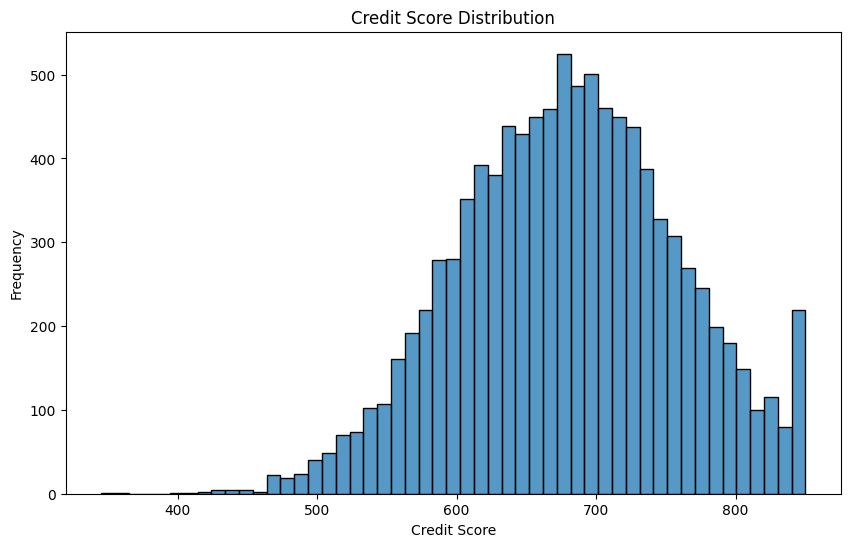

In [38]:
plt.figure(figsize=(10,6))
sns.histplot(loan_df['Credit_Score'])
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

b. Analyse how credit scores differ between defaulters and non-defaulters using a box plot

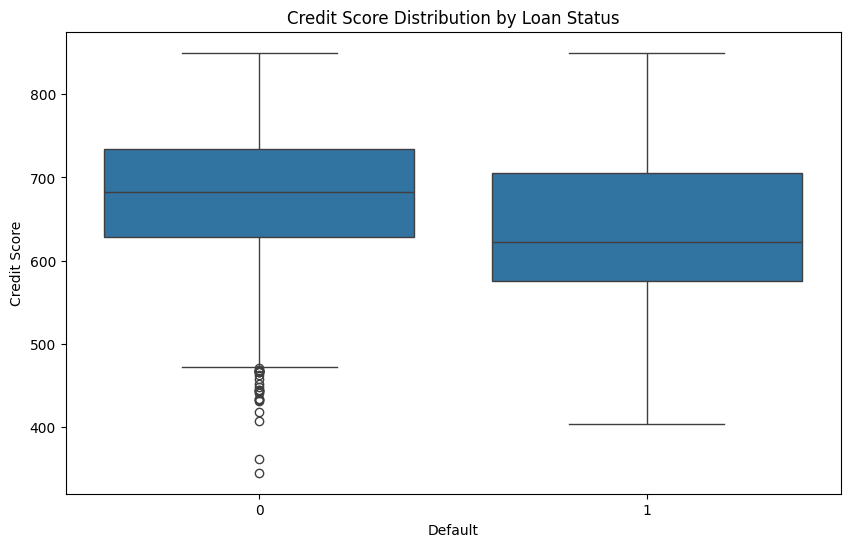

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Default', y='Credit_Score', data=loan_df)
plt.title('Credit Score Distribution by Loan Status')
plt.xlabel('Default')
plt.ylabel('Credit Score')
plt.show()

c. Predict whether a borrower is likely to default on a loan using Logistic 
Regression

In [26]:
X=loan_df.drop('Default', axis=1)
y=loan_df['Default']
X=pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)
model=LogisticRegression(solver='liblinear')

In [27]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': predictions})
comparison['Match'] = comparison['Actual'] == comparison['Predicted']
comparison.head(20)

,Actual,Predicted,Match
0,1,0,False
1,0,0,True
2,0,0,True
3,0,0,True
4,0,0,True
5,0,0,True
6,0,0,True
7,0,0,True
8,0,0,True
9,0,0,True


d. Generate Confusion matrix

In [42]:
confusion_matrix(y_test, predictions)

array([[1878,    0],
       [ 122,    0]])

e. Compute Accuracy Score of the model

In [43]:
Accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", Accuracy*100, "%")

Accuracy: 93.89999999999999 %


f. Generate a Classification report and find the Precision, Recall & F1-score of the model

In [44]:
report=classification_report(y_test, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1878
           1       0.00      0.00      0.00       122

    accuracy                           0.94      2000
   macro avg       0.47      0.50      0.48      2000
weighted avg       0.88      0.94      0.91      2000



/Users/ak20531344/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ak20531344/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ak20531344/Library/Python/3.12/lib/python/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi